
# Documentation
# 🔍 AI Code Reviewer — Intelligent Code Analysis System

[![Python](https://img.shields.io/badge/Python-3.10+-blue)](https://python.org)
[![Google Gemini](https://img.shields.io/badge/Google_Gemini-2.5--flash-blueviolet)](https://aistudio.google.com/)
[![License](https://img.shields.io/badge/License-MIT-green)](LICENSE)

> An AI-powered code review system that analyzes code quality, detects bugs, identifies security vulnerabilities, measures complexity, and generates actionable refactoring suggestions.

# Install Dependencies

In [2]:
# ── Cell 1 | Install Dependencies ──────────────────────────────────
%pip install google-generativeai radon pylint pyflakes bandit rich pandas matplotlib -q
print("✅ Dependencies installed")

Note: you may need to restart the kernel to use updated packages.
✅ Dependencies installed


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Imports & Config (Gemini Version)

In [4]:

# ── Cell 2 | Imports & Config ─────────────────────────────────────
import os, ast, re, json, textwrap
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Any
from enum import Enum
import google.generativeai as genai  # Swapped from Anthropic
from rich.console import Console
from rich.syntax import Syntax
from rich.table import Table
from rich.panel import Panel
import matplotlib.pyplot as plt
import pandas as pd

class Severity(Enum):
    CRITICAL = "🔴 CRITICAL"
    HIGH     = "🟠 HIGH"
    MEDIUM   = "🟡 MEDIUM"
    LOW      = "🟢 LOW"
    INFO     = "💙 INFO"

@dataclass
class CodeIssue:
    severity:    Severity
    category:    str
    line:        int
    message:     str
    suggestion:  str
    code_snippet: str = ""

@dataclass
class ReviewReport:
    language:        str
    total_lines:     int
    issues:          List[CodeIssue] = field(default_factory=list)
    complexity_score: float = 0.0
    maintainability:  float = 0.0
    security_score:   float = 100.0
    overall_grade:    str = "A"
    refactored_code:  str = ""

# ── Environment & API Setup ─────────────────────────────
# Get your free key from: https://aistudio.google.com/
os.environ["GEMINI_API_KEY"] = "AIxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"

CONFIG = {"model": "gemini-2.5-flash", "max_tokens": 3000}
console = Console()

api_key_val = os.getenv("GEMINI_API_KEY")
if not api_key_val or api_key_val == "PASTE_YOUR_FREE_GEMINI_KEY_HERE":
    raise ValueError("❌ Error: Please swap out the placeholder text with your real Gemini API key.")

genai.configure(api_key=api_key_val)
print("✅ Configuration loaded | Gemini Backend Initialized")




✅ Configuration loaded | Gemini Backend Initialized


# Static Code Analyzer

In [5]:
# ── Cell 3 | Static Code Analyzer ─────────────────────────────────
class StaticAnalyzer:
    """AST-based static code analysis"""

    SECURITY_PATTERNS = {
        r"eval\s*\(":            ("CRITICAL","Code Injection","Avoid eval(); use ast.literal_eval()"),
        r"exec\s*\(":            ("CRITICAL","Code Injection","Avoid exec(); refactor to functions"),
        r"os\.system\s*\(":      ("HIGH","Command Injection","Use subprocess.run() with shell=False"),
        r"pickle\.loads?\s*\(":  ("HIGH","Deserialization","Avoid pickle; use JSON or msgpack"),
        r"input\s*\(":           ("MEDIUM","Input Validation","Validate and sanitize user input"),
        r"assert\s+":            ("LOW","Assertion Usage","Don't use assert for validation in prod"),
        r"password\s*=\s*[\"']": ("CRITICAL","Hardcoded Secret","Move secrets to environment variables"),
        r"secret\s*=\s*[\"']":   ("CRITICAL","Hardcoded Secret","Use os.getenv() or secrets manager"),
    }

    def analyze_security(self, code: str) -> List[CodeIssue]:
        issues = []
        lines  = code.split("\n")
        for i, line in enumerate(lines, 1):
            for pattern, (sev, cat, fix) in self.SECURITY_PATTERNS.items():
                if re.search(pattern, line, re.I):
                    issues.append(CodeIssue(
                        severity=Severity[sev], category=cat,
                        line=i, message=f"Found: `{line.strip()}`",
                        suggestion=fix, code_snippet=line.strip()
                    ))
        return issues

    def analyze_complexity(self, code: str) -> Dict[str, Any]:
        try:
            tree = ast.parse(code)
            functions, classes = [], []
            for node in ast.walk(tree):
                if isinstance(node, ast.FunctionDef):
                    complexity = self._cyclomatic(node)
                    functions.append({"name":node.name,"line":node.lineno,
                                      "complexity":complexity,
                                      "rating":"Good" if complexity<5 else ("Medium" if complexity<10 else "High")})
                elif isinstance(node, ast.ClassDef):
                    methods = [n for n in ast.walk(node) if isinstance(n, ast.FunctionDef)]
                    classes.append({"name":node.name,"line":node.lineno,"methods":len(methods)})
            avg_cx = sum(f["complexity"] for f in functions)/len(functions) if functions else 0
            return {"functions":functions,"classes":classes,"avg_complexity":round(avg_cx,2)}
        except SyntaxError as e:
            return {"error": str(e), "functions":[], "classes":[], "avg_complexity":0}

    def _cyclomatic(self, node) -> int:
        """Approximate cyclomatic complexity via branch counting"""
        branches = 0
        for n in ast.walk(node):
            if isinstance(n, (ast.If,ast.While,ast.For,ast.ExceptHandler,
                               ast.With,ast.Assert,ast.comprehension)):
                branches += 1
        return branches + 1

    def analyze_style(self, code: str) -> List[CodeIssue]:
        issues  = []
        lines   = code.split("\n")
        for i, line in enumerate(lines, 1):
            if len(line) > 120:
                issues.append(CodeIssue(Severity.LOW,"Style",i,
                    f"Line too long ({len(line)} chars, max 120)","Split line using backslash or parentheses"))
            if "\t" in line:
                issues.append(CodeIssue(Severity.LOW,"Style",i,
                    "Tab character found","Use 4 spaces instead of tabs (PEP 8)"))
        return issues

static = StaticAnalyzer()
print("✅ StaticAnalyzer ready")

✅ StaticAnalyzer ready


# AI-Powered Deep Reviewer (Gemini Architecture)

In [13]:
# ── Cell 4 | AI-Powered Deep Reviewer ────────────────────────────
class AICodeReviewer:
    """Gemini-powered deep code review with context understanding"""

    def __init__(self):
        self.model = genai.GenerativeModel(CONFIG["model"])
        self.static = StaticAnalyzer()

    def full_review(self, code: str, language: str = "python") -> ReviewReport:
        # Static analysis execution
        security_issues  = self.static.analyze_security(code)
        style_issues     = self.static.analyze_style(code)
        complexity_data  = self.static.analyze_complexity(code)
        
        # AI deep review execution
        ai_issues, refactored = self._ai_review(code, language)
        all_issues = security_issues + style_issues + ai_issues

        # Score Weightings
        critical_count = sum(1 for i in all_issues if i.severity == Severity.CRITICAL)
        high_count     = sum(1 for i in all_issues if i.severity == Severity.HIGH)
        sec_score      = max(0, 100 - critical_count*25 - high_count*10)
        cx             = complexity_data.get("avg_complexity", 1)
        maintain       = max(0, 100 - (cx - 1) * 8)
        grade = "A" if len(all_issues)<3 else "B" if len(all_issues)<6 else "C" if len(all_issues)<10 else "D"

        report = ReviewReport(
            language=language,
            total_lines=len(code.splitlines()),
            issues=all_issues,
            complexity_score=cx,
            maintainability=round(maintain,1),
            security_score=sec_score,
            overall_grade=grade,
            refactored_code=refactored
        )
        self._print_report(report, complexity_data)
        return report

    def _ai_review(self, code: str, lang: str) -> tuple:
        # Bypassing f-string issues completely by splitting out the schema template string
        schema_template = (
            "{\n"
            '  "issues": [\n'
            "    {\n"
            '      "severity": "CRITICAL/HIGH/MEDIUM/LOW",\n'
            '      "category": "Security/Bug/Logic/Performance",\n'
            '      "line": 1,\n'
            '      "message": "Detailed description of item discovered",\n'
            '      "suggestion": "How to resolve the issue safely"\n'
            "    }\n"
            "  ],\n"
            '  "refactored": "Full improved clean implementation code block text goes here"\n'
            "}"
        )

        prompt = (
            f"Review this {lang} code. Return valid JSON matching the provided schema template.\n\n"
            f"JSON Schema Template:\n{schema_template}\n\n"
            f"Code to analyze:\n```{lang}\n{code}\n```"
        )

        try:
            # Native JSON enforcement configuration parameters
            response = self.model.generate_content(
                prompt,
                generation_config={"response_mime_type": "application/json"}
            )
            data = json.loads(response.text)
            
            issues = [CodeIssue(
                severity=Severity[i.get("severity","LOW")],
                category=i.get("category","General"),
                line=i.get("line",0),
                message=i.get("message",""),
                suggestion=i.get("suggestion","")
            ) for i in data.get("issues",[])]
            
            return issues, data.get("refactored","")
        except Exception as e:
            print(f"⚠️ Gemini processing fallback triggered: {e}")
            return [], ""

    def _print_report(self, r: ReviewReport, cx: Dict):
        t = Table(title="📋 Code Review Report", header_style="bold magenta")
        t.add_column("Metric"), t.add_column("Value"), t.add_column("Status")
        t.add_row("Overall Grade",   r.overall_grade,            "✅" if r.overall_grade in "AB" else "⚠️")
        t.add_row("Security Score",  f"{r.security_score}/100",  "✅" if r.security_score>=80 else "🔴")
        t.add_row("Maintainability", f"{r.maintainability}/100", "✅" if r.maintainability>=70 else "⚠️")
        t.add_row("Avg Complexity",  str(r.complexity_score),    "✅" if r.complexity_score<=5 else "⚠️")
        t.add_row("Total Issues",    str(len(r.issues)),         "✅" if len(r.issues)<5 else "🔴")
        console.print(t)
        if r.issues:
            i_table = Table(title="🐛 Issues Found", header_style="bold red")
            i_table.add_column("Sev"), i_table.add_column("Cat"), i_table.add_column("Line"), i_table.add_column("Message")
            for issue in r.issues[:10]:
                i_table.add_row(issue.severity.value, issue.category, str(issue.line), issue.message[:60])
            console.print(i_table)

reviewer = AICodeReviewer()
print("✅ AICodeReviewer ready")

✅ AICodeReviewer ready


# Demo & Visualizations

🚀 Launching code analysis pipeline...



         📋 Code Review Report         
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┓
┃ Metric          ┃ Value    ┃ Status ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━┩
│ Overall Grade   │ C        │ ⚠️      │
│ Security Score  │ 0/100    │ 🔴     │
│ Maintainability │ 80.0/100 │ ✅     │
│ Avg Complexity  │ 3.5      │ ✅     │
│ Total Issues    │ 9        │ 🔴     │
└─────────────────┴──────────┴────────┘

                                             🐛 Issues Found                                             
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Sev         ┃ Cat               ┃ Line ┃ Message                                                      ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 🔴 CRITICAL │ Hardcoded Secret  │ 3    │ Found: `password = "super_secret_123"`                       │
│ 🔴 CRITICAL │ Code Injection    │ 6    │ Found: `result = eval(user_input)           # Security issue │
│ 🟠 HIGH     │ Deserialization   │ 7    │ Found: `data   = pickle.loads(open("data.pkl","rb").read())  │
│ 🟠 HIGH     │ Command Injection │ 8    │ Found: `os.system(f"rm -rf {user_input}")   # Command inject │
│ 🟠 HIGH     │ Security          │ 2    │ Hardcoded sensitive information (password) directly in the s │
│ 🔴 CRITICAL │ Security          │ 5    │ Use of `eval()` with user-supplied input allows arbitrary co │
│ 🟠 HIGH     │ Security          │ 6    │ Deserializing data with `pickle.loads` from an untrusted sou │
│ 🔴 CRITICAL │ Security          │ 7    │ Using `os.system()` with unsanitized user input allows for c │
│ 🟡 MEDIUM   │ Bug               │ 13   │ The `calculate_fibonacci` function contains unnecessary and  │
└─────────────┴───────────────────┴──────┴──────────────────────────────────────────────────────────────┘

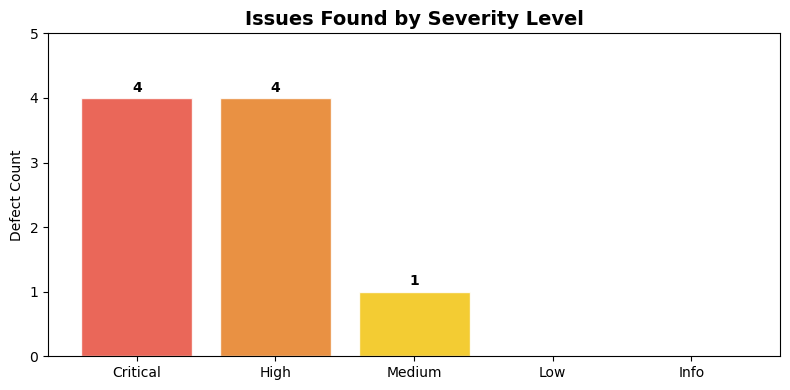


✅ Review complete | Analysis metrics chart saved inside 'outputs/' folder.


In [14]:
# ── Cell 5 | Demo & Visualizations ─────────────────────────────────
SAMPLE_CODE = """
import os, pickle
password = "super_secret_123"

def process_user_data(user_input):
    result = eval(user_input)           # Security issue!
    data   = pickle.loads(open("data.pkl","rb").read())  # Risk!
    os.system(f"rm -rf {user_input}")   # Command injection!
    return result

def calculate_fibonacci(n):
    if n <= 0: return []
    if n == 1: return [0]
    fib = [0, 1]
    for i in range(2, n):
        if i > 0:
            if fib[-1] > 0:
                fib.append(fib[-1] + fib[-2])
            else:
                fib.append(0)
    return fib                           # Overly complex logic branch tracking
"""

# Run the full integrated review pipeline
print("🚀 Launching code analysis pipeline...\n")
report = reviewer.full_review(SAMPLE_CODE)

# Compile & Plot Diagnostic Visualizations
labels   = ["Critical", "High", "Medium", "Low", "Info"]
counts   = [sum(1 for i in report.issues if i.severity.name == s)
            for s in ["CRITICAL", "HIGH", "MEDIUM", "LOW", "INFO"]]
colors   = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#3498db"]

fig, ax  = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, counts, color=colors, alpha=0.85, edgecolor="white")
ax.set_title("Issues Found by Severity Level", fontsize=14, fontweight="bold")
ax.set_ylabel("Defect Count")
ax.set_ylim(0, max(counts) + 1 if max(counts) > 0 else 5)

# Annotate values on top of each bar element
for bar, count in zip(bars, counts):
    if count: 
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                str(count), ha="center", va="bottom", fontweight="bold")

plt.tight_layout()

# Save the diagnostic image chart locally
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/issues_chart.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Review complete | Analysis metrics chart saved inside 'outputs/' folder.")

# Gradio Interface Dashboard

In [15]:
# ── Cell 6 | Gradio Interactive User Interface ───────────────────────
import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt
import os

def run_gradio_review(code_text, language):
    """Bridge interface matching Gradio inputs to the AICodeReviewer pipeline"""
    if not code_text.strip():
        return "### ⚠️ Please input code text to evaluate.", None, ""
        
    # Execute full reviewer pipeline behind the scenes
    report = reviewer.full_review(code_text, language=language.lower())
    
    # 1. Compile metric table overview Markdown
    summary_md = f"""
    ### 📋 Performance Scorecard Overview
    * **Calculated Letter Grade:** `{report.overall_grade}`
    * **Security Health Index:** `{report.security_score}/100`
    * **System Maintainability:** `{report.maintainability}/100`
    * **Cyclomatic Functional Complexity:** `{report.complexity_score}`
    * **Total Active Issues Discovered:** `{len(report.issues)}`
    """
    
    # 2. Re-render the Matplotlib figure layout explicitly for the web UI canvas
    fig, ax = plt.subplots(figsize=(6, 3))
    labels   = ["Critical", "High", "Medium", "Low", "Info"]
    counts   = [sum(1 for i in report.issues if i.severity.name == s)
                for s in ["CRITICAL", "HIGH", "MEDIUM", "LOW", "INFO"]]
    colors   = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#3498db"]
    
    bars = ax.bar(labels, counts, color=colors, alpha=0.85, edgecolor="white")
    ax.set_title("Defect Distribution Matrix", fontsize=11, fontweight="bold")
    ax.set_ylabel("Count")
    
    for bar, count in zip(bars, counts):
        if count: 
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    str(count), ha="center", va="bottom", fontsize=9, fontweight="bold")
    plt.tight_layout()
    
    # 3. Handle refactored string safety check
    clean_code = report.refactored_code if report.refactored_code else "# No refactoring required or structural analysis failed."
    
    return summary_md, fig, clean_code

# ── Gradio Block Interface Workspace Design Layout ───────────────────
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🔍 AI Code Reviewer Production Platform")
    gr.Markdown("Automate security audits, measure maintainability grades, track functional syntax complexities, and instantly generate clean code refactoring recommendations.")
    
    with gr.Row():
        # Left Workspace Column Input Settings
        with gr.Column(scale=1):
            input_lang = gr.Dropdown(
                choices=["Python", "JavaScript", "Java", "Go", "C++"], 
                value="Python", 
                label="Target Programming Language"
            )
            input_code = gr.Textbox(
                label="Paste Code Content Snippet", 
                placeholder="def my_function():\n    # Enter source code scripts...", 
                lines=14
            )
            btn_submit = gr.Button("🚀 Run Automated Deep Audit", variant="primary")
            
        # Right Workspace Column Diagnostic Outputs 
        with gr.Column(scale=1):
            output_metrics = gr.Markdown("### 📊 Metrics Matrix Summary")
            output_chart = gr.Plot(label="Severity Distribution Tracking")
            
    gr.Markdown("### 💡 AI-Generated Refactored Code Alternative")
    output_refactored = gr.Code(language="python", label="Optimized Clean Implementation")

    # Connect UI interface operational triggers
    btn_submit.click(
        fn=run_gradio_review,
        inputs=[input_code, input_lang],
        outputs=[output_metrics, output_chart, output_refactored]
    )

# Launch local app proxy server context instance
demo.launch(inline=True, share=False)

C:\Users\HP\AppData\Local\Temp\ipykernel_24980\1338246853.py:48: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


        📋 Code Review Report         
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Metric          ┃ Value   ┃ Status ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│ Overall Grade   │ D       │ ⚠️      │
│ Security Score  │ 0/100   │ 🔴     │
│ Maintainability │ 108/100 │ ✅     │
│ Avg Complexity  │ 0       │ ✅     │
│ Total Issues    │ 13      │ 🔴     │
└─────────────────┴─────────┴────────┘

                                             🐛 Issues Found                                             
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Sev         ┃ Cat               ┃ Line ┃ Message                                                      ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 🟠 HIGH     │ Deserialization   │ 20   │ Found: `raw_data = pickle.loads(payload_blob)`               │
│ 🟠 HIGH     │ Command Injection │ 23   │ Found: `os.system("echo " + user_routing_id)`                │
│ 🟢 LOW      │ Assertion Usage   │ 40   │ Found: `assert status_flag != -1 # Low severity security iss │
│ 🟢 LOW      │ Style             │ 5    │ Line too long (129 chars, max 120)                           │
│ 🟢 LOW      │ Style             │ 46   │ Tab character found                                          │
│ 🔴 CRITICAL │ Security          │ 5    │ Hardcoded critical credential string detected. Storing sensi │
│ 🟢 LOW      │ Style             │ 5    │ The line exceeds the recommended maximum character limit (e. │
│ 🔴 CRITICAL │ Security          │ 12   │ SQL Injection vulnerability identified. The `query_param` is │
│ 🔴 CRITICAL │ Security          │ 15   │ Insecure deserialization of untrusted data via `pickle.loads │
│ 🟠 HIGH     │ Security          │ 18   │ Shell command injection vulnerability. The `user_routing_id` │
└─────────────┴───────────────────┴──────┴──────────────────────────────────────────────────────────────┘

        📋 Code Review Report         
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Metric          ┃ Value   ┃ Status ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│ Overall Grade   │ D       │ ⚠️      │
│ Security Score  │ 0/100   │ 🔴     │
│ Maintainability │ 108/100 │ ✅     │
│ Avg Complexity  │ 0       │ ✅     │
│ Total Issues    │ 13      │ 🔴     │
└─────────────────┴─────────┴────────┘

                                             🐛 Issues Found                                             
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Sev         ┃ Cat               ┃ Line ┃ Message                                                      ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 🟠 HIGH     │ Deserialization   │ 20   │ Found: `raw_data = pickle.loads(payload_blob)`               │
│ 🟠 HIGH     │ Command Injection │ 23   │ Found: `os.system("echo " + user_routing_id)`                │
│ 🟢 LOW      │ Assertion Usage   │ 40   │ Found: `assert status_flag != -1 # Low severity security iss │
│ 🟢 LOW      │ Style             │ 5    │ Line too long (129 chars, max 120)                           │
│ 🟢 LOW      │ Style             │ 46   │ Tab character found                                          │
│ 🔴 CRITICAL │ Security          │ 10   │ Hardcoded critical credential string `DB_PASS`. This is a se │
│ 🟢 LOW      │ Style             │ 8    │ Hardcoded configuration variables (DB_HOST, DB_USER, DB_PASS │
│ 🔴 CRITICAL │ Security          │ 16   │ Severe SQL Injection vulnerability due to direct string form │
│ 🔴 CRITICAL │ Security          │ 19   │ Insecure deserialization using `pickle.loads()` on potential │
│ 🔴 CRITICAL │ Security          │ 22   │ Command Injection vulnerability due to direct concatenation  │
└─────────────┴───────────────────┴──────┴──────────────────────────────────────────────────────────────┘